Install & Import Libraries

In [707]:
!pip install wfdb neurokit2 imbalanced-learn

In [708]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

Load MIT-BIH ECG Data

In [709]:
train_records = ["100", "101", "102", "103"]
test_records = ["104", "105"]
data_path = "mitdb/"

wfdb.dl_database("mitdb", data_path)

# =========================
# 4. Function to build dataset
# =========================
def build_dataset(record_list):
    X, y = [], []

    for record_name in record_list:
        record = wfdb.rdsamp(data_path + record_name)
        signal = record[0][:, 0]
        fs = record[1]['fs']

        # ECG processing
        signals, info = nk.ecg_process(signal, sampling_rate=fs)
        cleaned = signals["ECG_Clean"]
        rpeaks = info["ECG_R_Peaks"]

        # Load annotations
        annotation = wfdb.rdann(data_path + record_name, 'atr')
        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        labels = np.array([0 if s == 'N' else 1 for s in ann_symbols])

        window_size = int(0.4 * fs)
        half_window = window_size // 2

        prev_r = None

        for r in rpeaks:
            start = r - half_window
            end = r + half_window

            if start > 0 and end < len(cleaned):
                beat = cleaned[start:end]

                # Align label
                idx = np.argmin(np.abs(ann_samples - r))

                if abs(ann_samples[idx] - r) < 50:
                    label = labels[idx]

                    # Normalize beat
                    beat = (beat - np.mean(beat)) / (np.std(beat) + 1e-8)

                    # === Feature engineering ===
                    # RR interval
                    rr = (r - prev_r) / fs if prev_r is not None else 0
                    prev_r = r

                    # amplitude
                    amplitude = np.max(beat) - np.min(beat)

                    # energy
                    energy = np.sum(beat**2)

                    # Combine features
                    beat_features = np.concatenate([beat, [rr, amplitude, energy]])

                    X.append(beat_features)
                    y.append(label)

    return np.array(X), np.array(y)


Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

Build Test Set

In [710]:
X_train, y_train = build_dataset(train_records)
X_test, y_test = build_dataset(test_records)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8373, 147)
Test shape: (4721, 147)


Handle Imbalance

In [711]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [6275 6275]


Convert to Array

In [712]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12550, 147)
Test: (4721, 147)


Plot Raw ECG Signal

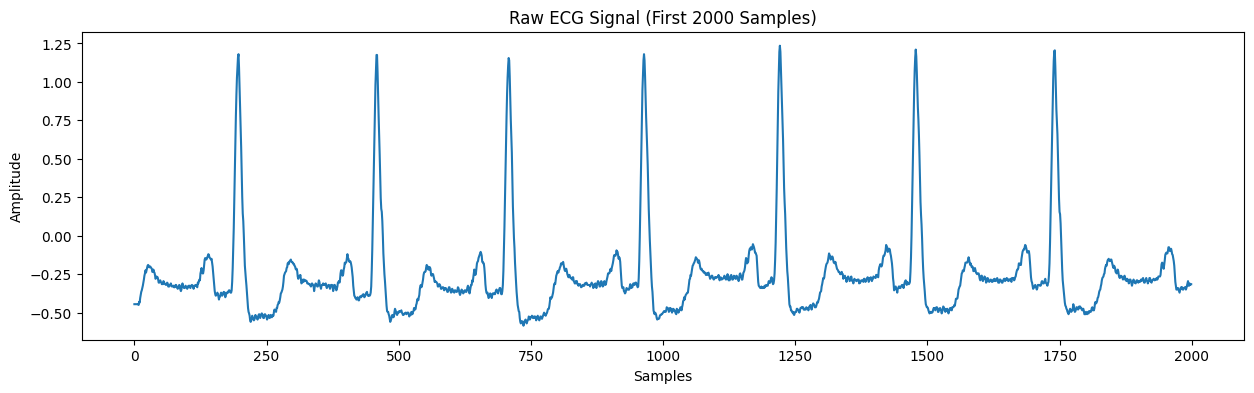

In [713]:
plt.figure(figsize=(15,4))
plt.plot(signal[:2000])
plt.title("Raw ECG Signal (First 2000 Samples)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Clean / Filter ECG Signal

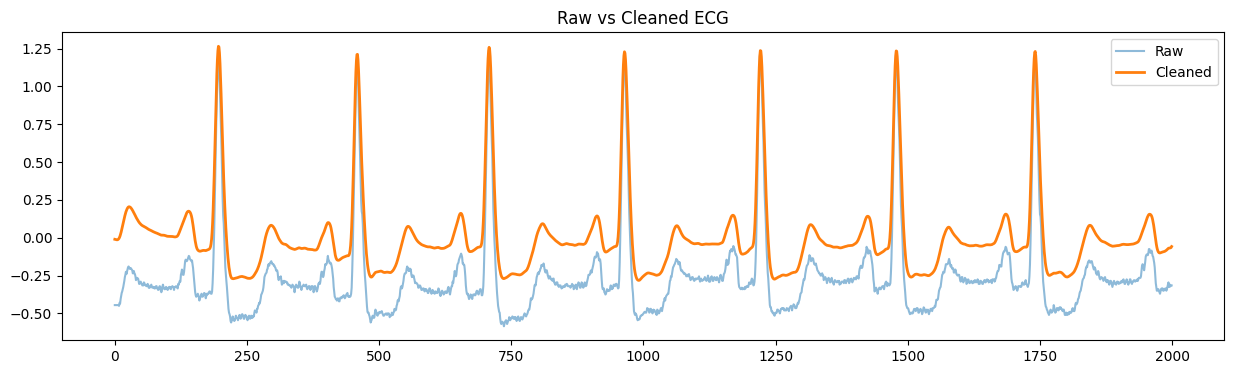

In [714]:
cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")

plt.figure(figsize=(15,4))
plt.plot(signal[:2000], label="Raw", alpha=0.5)
plt.plot(cleaned[:2000], label="Cleaned", linewidth=2)
plt.legend()
plt.title("Raw vs Cleaned ECG")
plt.show()

Detect R-Peaks (QRS Complex)

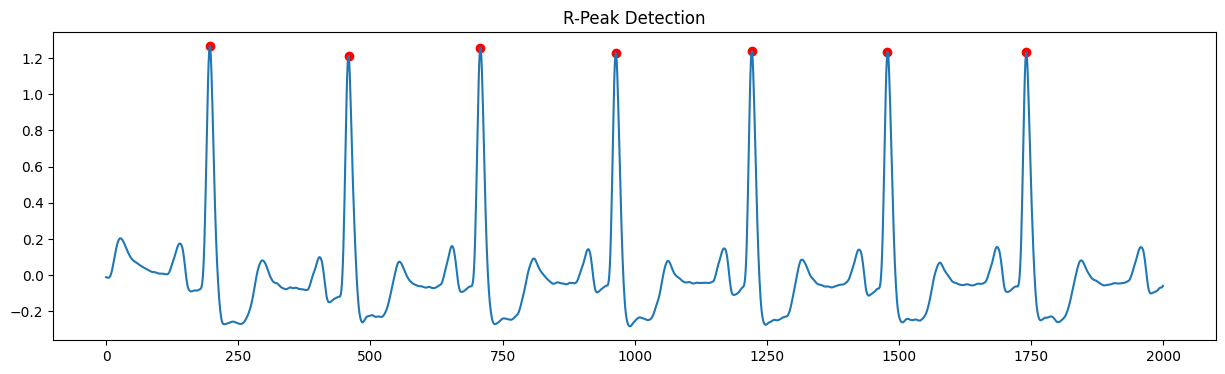

Number of R-Peaks Detected: 2576


In [715]:
signals, info = nk.ecg_process(signal, sampling_rate=fs)
rpeaks = info["ECG_R_Peaks"]

plt.figure(figsize=(15,4))
plt.plot(cleaned[:2000])
plt.scatter(rpeaks[rpeaks < 2000], cleaned[rpeaks[rpeaks < 2000]], color='red')
plt.title("R-Peak Detection")
plt.show()

print("Number of R-Peaks Detected:", len(rpeaks))

Segment Heartbeats

In [716]:
window_size = int(0.6 * fs)
half_window = window_size

beats = []

for r in rpeaks:
  start = r - half_window
  end = r + half_window

  if start > 0 and end < len(cleaned):
    beat = cleaned[start:end]
    beats.append(beat)

beats = np.array(beats)
print("Shape of beats:", beats.shape)

Shape of beats: (2575, 432)


Plot Individual Heartbeats

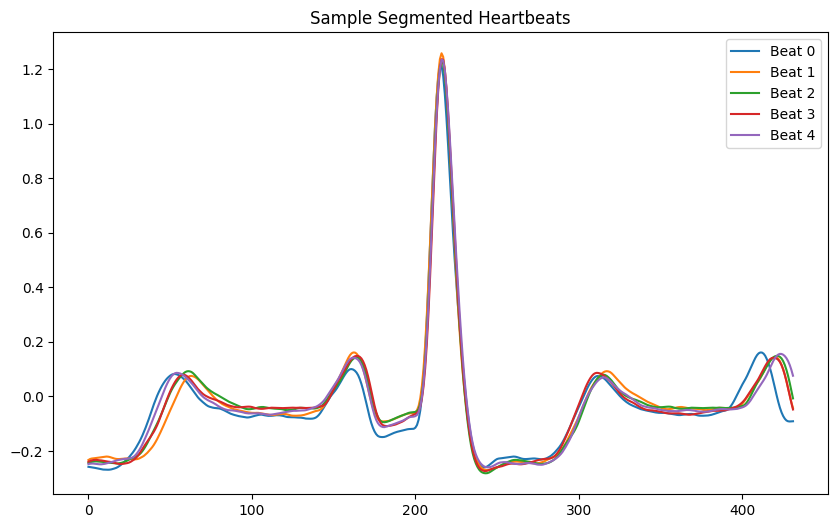

In [717]:
plt.figure(figsize=(10,6))

for i in range(5):
  plt.plot(beats[i], label=f"Beat {i}")

plt.title("Sample Segmented Heartbeats")
plt.legend()
plt.show()

Visualize Average Heartbeat

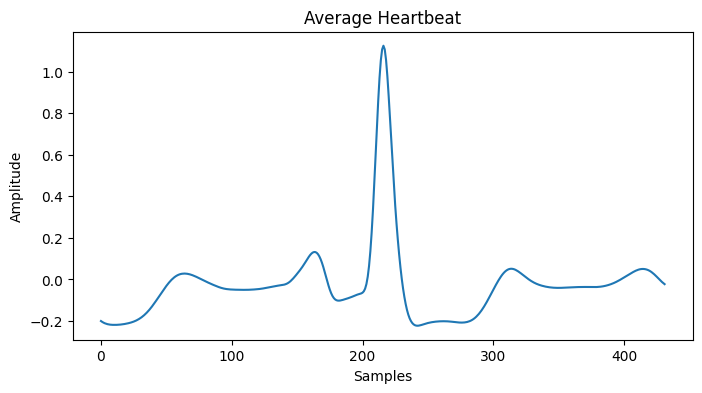

In [718]:
avg_beat = np.mean(beats, axis=0)

plt.figure(figsize=(8,4))
plt.plot(avg_beat)
plt.title("Average Heartbeat")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Load Annotations (Ground Truth)

In [719]:
annotation = wfdb.rdann(data_path + record_name, 'atr')

ann_samples = annotation.sample
ann_symbols = annotation.symbol

print("First 10 annotations:")
for i in range(10):
  print(ann_samples[i], ann_symbols[i])

First 10 annotations:
67 +
197 N
459 N
708 N
965 N
1222 N
1479 N
1741 N
2015 N
2287 N


Map Labels -> Normal vs Arrythmia

In [720]:
def label_map(symbol):
  if symbol == 'N':
    return 0
  else:
    return 1

labels = np.array([label_map(s) for s in ann_symbols])

Align Labels with R-Peaks

In [721]:
beat_labels = []

for r in rpeaks:
  idx = np.argmin(np.abs(ann_samples - r))
  beat_labels.append(labels[idx])

beat_labels = np.array(beat_labels)

print("Beats:", beats.shape)
print("Labels:", beat_labels.shape)

Beats: (2575, 432)
Labels: (2576,)


Clean Dataset (Remove Mismatch)

In [722]:
min_len = min(len(beats), len(beat_labels))
X = beats[:min_len]
y = beat_labels[:min_len]

print("Final Dataset:", X.shape, y.shape)

Final Dataset: (2575, 432) (2575,)


Train / Test Split

In [723]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_flat, y_train)

Train Classifier (Random Forest)

In [724]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res,
    test_size=0.2,
    stratify=y_train_res,
    random_state=42
)

Train Random Forest on Training Split

In [725]:
rf_model.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

Threshold Tuning

In [726]:
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

target_recall = 0.80
idx = np.where(recall >= target_recall)[0][0]
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_thr_rf = thresholds[best_idx]

print("RF Best Threshold (validation):", best_thr_rf)

RF Best Threshold (validation): 0.6944523809523809


Proper evaluation

In [727]:
y_prob_rf = rf_model.predict_proba(X_test_flat)[:, 1]
y_pred_rf = (y_prob_rf > 0.3).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\nRandom Forest Results (Test Set)")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest Results (Test Set)
[[2409  243]
 [  46 2023]]
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      2652
           1       0.89      0.98      0.93      2069

    accuracy                           0.94      4721
   macro avg       0.94      0.94      0.94      4721
weighted avg       0.94      0.94      0.94      4721

ROC-AUC: 0.9432759831076721


Quick Checks

In [728]:
print("Train size:", X_train.shape, np.bincount(y_train))
print("Test size:", X_test.shape, np.bincount(y_test))

Train size: (12550, 147) [6275 6275]
Test size: (4721, 147) [2652 2069]


Confusion Matrix

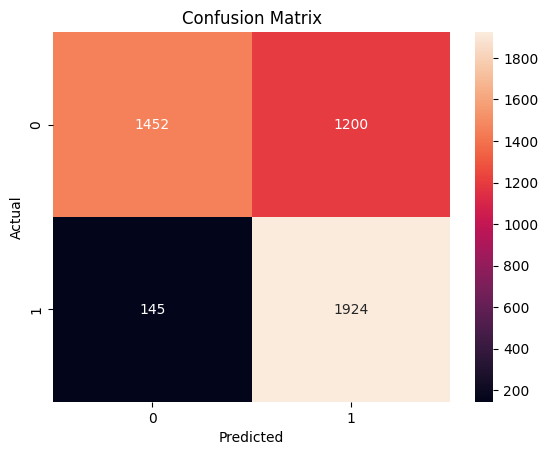

In [729]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Class Distribution

In [730]:
unique, counts = np.unique(y, return_counts=True)

print("Class Distribution:")
for u, c in zip(unique,counts):
  print("Normal" if u == 0 else "Arrythmia", ":", c)

Class Distribution:
Normal : 2521
Arrythmia : 54


Prepare Data for Small Neural Network (SNN)

In [731]:
X_nn = X.reshape(X.shape[0], -1)

print("NN imput shape:", X_nn.shape)

NN imput shape: (2575, 432)


Normalize Features

In [732]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_nn = scaler.fit_transform(X_nn)

Train / Test Split

In [733]:
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y, test_size=0.2, random_state=42, stratify=y
)

Build Small Neural Network (SNN)

In [734]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [735]:
model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 128)            │        55,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,793 (257.00 KB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [736]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_nn)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

history_nn = model_nn.fit(
    X_train_nn,
    y_train_nn,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Class weights: {np.int64(0): np.float64(0.510659395141299), np.int64(1): np.float64(23.953488372093023)}
Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8556 - loss: 1.6691 - val_accuracy: 0.8835 - val_loss: 0.4162
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8653 - loss: 0.9116 - val_accuracy: 0.8883 - val_loss: 0.4197
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8726 - loss: 0.3853 - val_accuracy: 0.9223 - val_loss: 0.3754
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8708 - loss: 0.7134 - val_accuracy: 0.8835 - val_loss: 0.3808
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8926 - loss: 0.4238 - val_accuracy: 0.9248 - val_loss: 0.3130
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9120 - loss: 0.3371 - val_accuracy: 0.9490 - val_loss: 0.3000
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.7959 - val_accuracy: 0.9223 - val_loss: 0.3669
Epoch 8/20
52

Evaluate Model

In [737]:
loss,acc = model_nn.evaluate(X_test_nn, y_test_nn)
print("NN Test Accuracy:", acc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9437 - loss: 0.1887 
NN Test Accuracy: 0.9436893463134766


Detailed Metrics

In [738]:
y_pred_prob = model_nn.predict(X_test_nn)
y_pred = (y_pred_prob > 0.6).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test_nn, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       504
           1       0.38      0.73      0.50        11

    accuracy                           0.97       515
   macro avg       0.69      0.85      0.74       515
weighted avg       0.98      0.97      0.97       515



NOTE: Logistic Regression instead of Linear Regression as it is perfect for binary classification

Prepare Data

In [739]:
X_lr = X.reshape(X.shape[0], -1)

Normalize Features

In [740]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_lr = scaler.fit_transform(X_lr)

Train / Test Split

In [741]:
from sklearn.model_selection import train_test_split

X_trian_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

Train Logistic Regression

In [742]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_trian_lr, y_train_lr)

LogisticRegression(class_weight='balanced', max_iter=1000)

Evaluate Model

In [743]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = model_lr.predict(X_test_lr)

print("Logistic Regression Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test_lr, y_pred_lr))

Logistic Regression Accuracy: 0.9572815533980582

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       504
           1       0.30      0.73      0.42        11

    accuracy                           0.96       515
   macro avg       0.65      0.84      0.70       515
weighted avg       0.98      0.96      0.97       515



Tune Class Weights

In [744]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={0:1, 1:2})

Find Best Threshold

In [745]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Remove last element (no threshold for it)
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

valid = np.where(recall >= 0.90)[0]
best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

print("Threshold:", best_thresh)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Best threshold: 0.64164495
Threshold: 0.3009265873015873
Precision: 0.8616867469879518
Recall: 0.8641855969067183


Add Post-Processing Filter

In [746]:
y_pred_smoothed = y_pred.copy()

for i in range(1, len(y_pred)-1):
    if y_pred[i] == 1 and y_pred[i-1] == 0 and y_pred[i+1] == 0:
        y_pred_smoothed[i] = 0

Verify with Actual Predictions

In [747]:
y_pred = (y_prob > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      2652
           1       0.86      0.86      0.86      2069

    accuracy                           0.88      4721
   macro avg       0.88      0.88      0.88      4721
weighted avg       0.88      0.88      0.88      4721



Install & Imports for Convolutional Neural Networks

In [748]:
!pip install tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

Reshape Data for CNN

In [749]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print(X_train_cnn.shape, X_test_cnn.shape)

(12550, 147, 1) (4721, 147, 1)


Build CNN Model

In [750]:
model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 143, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 143, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 71, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 67, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 31, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 31, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,305 (1.11 MB)

 Trainable params: 289,857 (1.11 MB)

 Non-trainable params: 448 (1.75 KB)

Handle Imbalance

In [751]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0)}


Train CNN

In [752]:
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

history = model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - accuracy: 0.9937 - auc: 0.9994 - loss: 0.0197 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0018
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 7.5714e-05
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 5.2591e-04 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 6.5216e-06
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9992 - auc: 0.9999 - loss: 0.0021 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 9.4569e-06
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 9.9022e-04 - val_accuracy: 0.9996 - val_auc: 0.0000e+00 - val_loss: 3.0604e-04
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9998 - auc: 0.9997 - loss: 0.0031 - val_accuracy: 0.9988 - val_auc: 0.0000e+00 -

Evaluate CNN

In [753]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_prob = model.predict(X_test_cnn).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Confusion Matrix:
 [[   0 2652]
 [   0 2069]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2652
           1       0.44      1.00      0.61      2069

    accuracy                           0.44      4721
   macro avg       0.22      0.50      0.30      4721
weighted avg       0.19      0.44      0.27      4721

ROC-AUC: 0.9056311951110518


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Threshold Tuning

In [754]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)



Best Threshold: 0.9776563
